<a href="https://colab.research.google.com/github/astridcvr/daily-ml-practice/blob/main/day_10_dates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

💾 File saved as 'sales_by_month.csv'


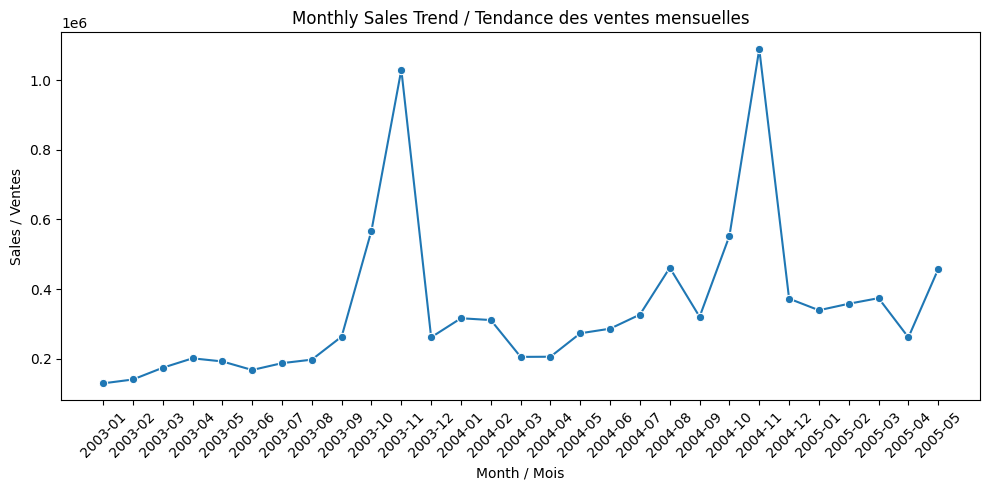

Preview of monthly sales data / Aperçu des ventes mensuelles :
   ORDER_YEAR  ORDER_MONTH      SALES   PERIOD
0        2003            1  129753.60  2003-01
1        2003            2  140836.19  2003-02
2        2003            3  174504.90  2003-03
3        2003            4  201609.55  2003-04
4        2003            5  192673.11  2003-05


In [7]:
# ============================================================
# Day 10: Date Handling / Jour 10 : Gestion des dates
# Extract month from the 'ORDERDATE' column for time-based analysis.
# Extraire le mois de la colonne 'ORDERDATE' pour l'analyse temporelle.
# ============================================================

# === 1. Import libraries / Importer les bibliothèques ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === 2. Load cleaned data / Charger les données nettoyées ===
url= "https://raw.githubusercontent.com/astridcvr/daily-ml-practice/main/data/cleaned_sales_data.csv"
df = pd.read_csv(url, encoding="latin")

# === 3. Convert 'ORDERDATE' to datetime / Convertir 'ORDERDATE' en datetime ===
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], errors='coerce')

# === 4. Extract month and year / Extraire le mois et l'année ===
df['ORDER_MONTH'] = df['ORDERDATE'].dt.month
df['ORDER_YEAR'] = df['ORDERDATE'].dt.year

# === 5. Group sales by month / Regrouper les ventes par mois ===
monthly_sales = df.groupby(['ORDER_YEAR', 'ORDER_MONTH'])['SALES'].sum().reset_index()

# === 6. Create a readable month-year column / Créer une colonne lisible mois-année ===
monthly_sales['PERIOD'] = monthly_sales['ORDER_YEAR'].astype(str) + '-' + monthly_sales['ORDER_MONTH'].astype(str).str.zfill(2)

# === 7. Save the new dataset / Enregistrer le nouveau jeu de données ===
monthly_sales.to_csv("sales_by_month.csv", index=False)
print("💾 File saved as 'sales_by_month.csv'")

# === 8. Visualization / Visualisation ===
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_sales, x='PERIOD', y='SALES', marker='o')
plt.title("Monthly Sales Trend / Tendance des ventes mensuelles")
plt.xlabel("Month / Mois")
plt.ylabel("Sales / Ventes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# === 9. Display sample output / Afficher un échantillon de sortie ===
print("Preview of monthly sales data / Aperçu des ventes mensuelles :")
print(monthly_sales.head())
